## SETUP

In [1]:
!pip install timm --quiet

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/derm7pt.zip" "/content/"
!mkdir -p /content/data_derm7pt
!unzip -q /content/derm7pt.zip -d /content/data_derm7pt
!rm /content/derm7pt.zip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
SEED           = 42
IMG_SIZE       = 224
BATCH_SIZE     = 16
NUM_CLASSES    = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROJECT_ROOT = Path('/content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT')

DERM_DIR = Path('/content/data_derm7pt/derm7pt/release_v0')
SPLIT_DIR  = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR   = PROJECT_ROOT / 'checkpoints'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'ph06_evaluation_outputs'
LOG_DIR    = PROJECT_ROOT / 'logs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL2IDX = {'nevus': 0, 'mel': 1, 'sk': 2, 'misc': 3, 'bcc': 4}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}
CLASS_NAMES = [IDX2LABEL[i] for i in range(NUM_CLASSES)]

print('Setup & Cấu hình hoàn tất trên Colab!')

Setup & Cấu hình hoàn tất trên Colab!


## DATASET & DATALOADER

In [4]:
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['img_path']).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            img = self.transform(img)
        return img, label

# Load CSV
df_test = pd.read_csv(SPLIT_DIR / 'derm7pt_test.csv')
if 'label_idx' not in df_test.columns:
    df_test['label_idx'] = df_test['label'].map(LABEL2IDX)

print("Đang đồng bộ đường dẫn Test set...")
real_image_paths = {}
for root, dirs, files in os.walk(DERM_DIR / 'images'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            real_image_paths[file.lower()] = os.path.join(root, file).replace('\\', '/')

def get_real_path(csv_path):
    filename = str(csv_path).replace('\\', '/').split('/')[-1].lower()
    return real_image_paths.get(filename, None)

df_test['img_path'] = df_test['img_path'].apply(get_real_path)
df_test = df_test.dropna(subset=['label_idx', 'img_path']).reset_index(drop=True)

test_dataset = SkinDataset(df_test, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Test set: {len(df_test)} ảnh | {len(test_loader)} batches')

Đang đồng bộ đường dẫn Test set...
Test set: 395 ảnh | 25 batches


## LOAD MÔ HÌNH ĐÃ FINE-TUNE

In [5]:
def load_vit_model(ckpt_path, num_classes, device):
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=7)
    in_features = model.head.in_features
    model.head  = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f'✅ Loaded: {ckpt_path} — Val Acc khi lưu: {ckpt["val_acc"]:.4f}')
    return model

model_vit = load_vit_model(CKPT_DIR / 'vit_derm7pt_best.pth', NUM_CLASSES, DEVICE)

✅ Loaded: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/checkpoints/vit_derm7pt_best.pth — Val Acc khi lưu: 0.7635


## PREDICT TOÀN BỘ TEST SET

In [6]:
def predict_all(model, loader, device):
    all_preds, all_labels, all_probs = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs    = imgs.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = predict_all(model_vit, test_loader, DEVICE)
print(f'Dự đoán xong {len(y_true)} mẫu test.')

Dự đoán xong 395 mẫu test.


## TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ

In [7]:
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('\n' + '═'*50)
print('  KẾT QUẢ ĐÁNH GIÁ — ViT TRÊN DERM7PT TEST SET')
print('═'*50)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('═'*50)

print('\nClassification Report (per class):')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Lưu kết quả
results_df = pd.DataFrame({
    'Model'    : ['ViT (fine-tune Derm7pt)'],
    'Accuracy' : [round(acc, 4)],
    'Precision': [round(precision, 4)],
    'Recall'   : [round(recall, 4)],
    'F1-Score' : [round(f1, 4)],
})
results_df.to_csv(OUTPUT_DIR / 'vit_metrics_summary.csv', index=False)
print(f'\nĐã lưu metric tại: {OUTPUT_DIR}/vit_metrics_summary.csv')


══════════════════════════════════════════════════
  KẾT QUẢ ĐÁNH GIÁ — ViT TRÊN DERM7PT TEST SET
══════════════════════════════════════════════════
  Accuracy  : 0.7823 (78.23%)
  Precision : 0.7825
  Recall    : 0.7823
  F1-Score  : 0.7813
══════════════════════════════════════════════════

Classification Report (per class):
              precision    recall  f1-score   support

       nevus       0.85      0.87      0.86       219
         mel       0.73      0.73      0.73       101
          sk       0.57      0.63      0.60        19
        misc       0.63      0.60      0.62        40
         bcc       0.82      0.56      0.67        16

    accuracy                           0.78       395
   macro avg       0.72      0.68      0.69       395
weighted avg       0.78      0.78      0.78       395


Đã lưu metric tại: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/results/ph06_evaluation_outputs/vit_metrics_summary.csv


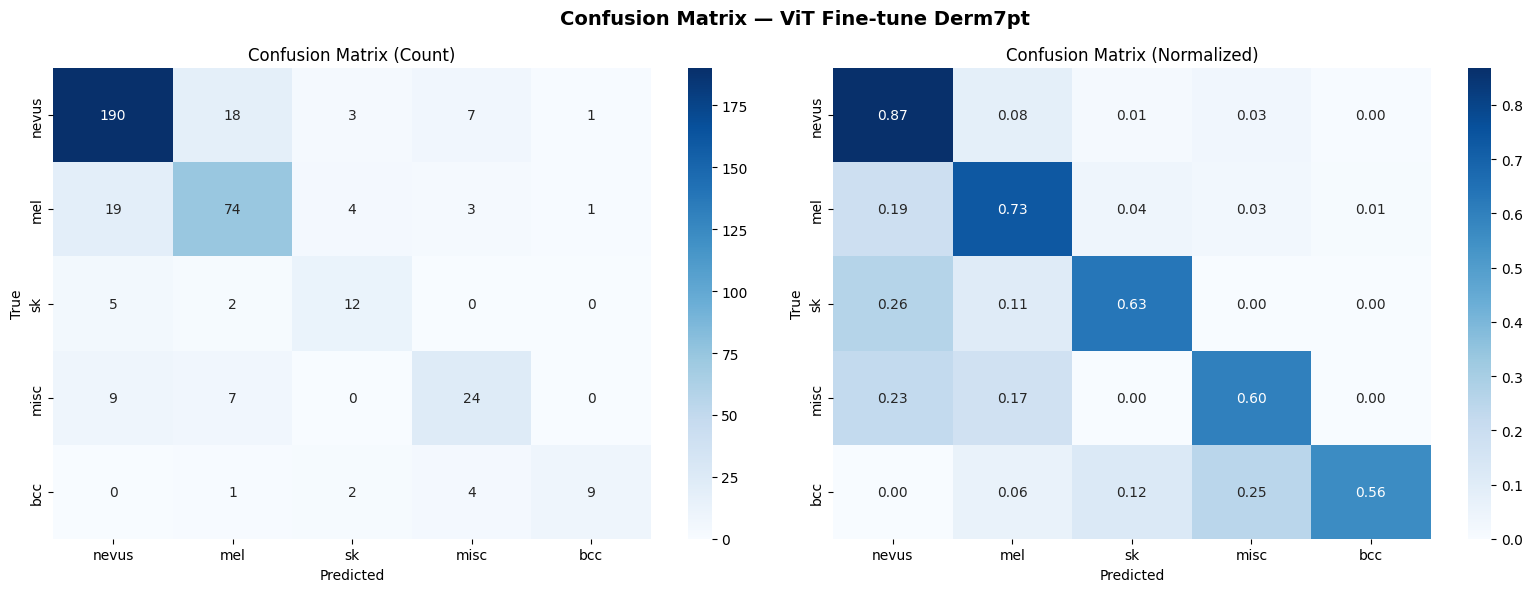

Đã lưu confusion matrix.


In [8]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — ViT Fine-tune Derm7pt', fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Count)')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'vit_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu confusion matrix.')

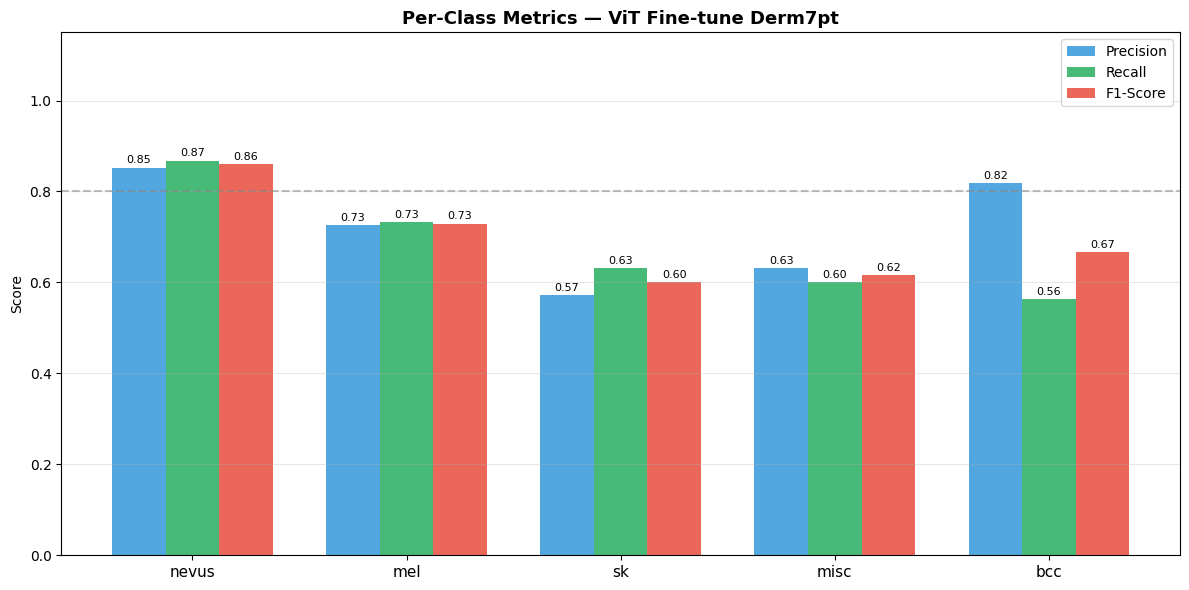

Đã lưu biểu đồ per-class metrics.


In [9]:
precision_per = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per    = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per        = f1_score(y_true, y_pred, average=None, zero_division=0)

x = np.arange(NUM_CLASSES)
w = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w,   precision_per, w, label='Precision', color='#3498DB', alpha=0.85)
ax.bar(x,       recall_per,    w, label='Recall',    color='#27AE60', alpha=0.85)
ax.bar(x + w,   f1_per,        w, label='F1-Score',  color='#E74C3C', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Metrics — ViT Fine-tune Derm7pt', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')

for i in range(NUM_CLASSES):
    ax.text(i - w,   precision_per[i] + 0.01, f'{precision_per[i]:.2f}', ha='center', fontsize=8)
    ax.text(i,       recall_per[i]    + 0.01, f'{recall_per[i]:.2f}',    ha='center', fontsize=8)
    ax.text(i + w,   f1_per[i]        + 0.01, f'{f1_per[i]:.2f}',        ha='center', fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'vit_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ per-class metrics.')

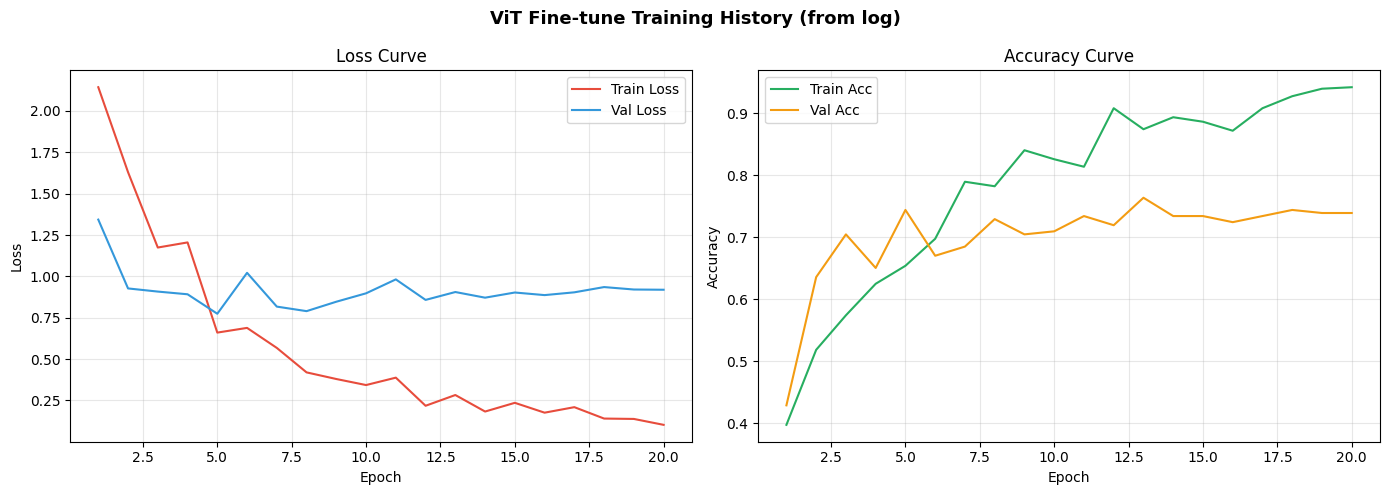

Đã vẽ training history từ log file.


In [10]:
log_path = LOG_DIR / 'vit_derm7pt_finetune.log'
if log_path.exists():
    log_df = pd.read_csv(log_path, header=None,
                         names=['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(log_df['epoch'], log_df['train_loss'], label='Train Loss', color='#E74C3C')
    axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='Val Loss',   color='#3498DB')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(log_df['epoch'], log_df['train_acc'], label='Train Acc', color='#27AE60')
    axes[1].plot(log_df['epoch'], log_df['val_acc'],   label='Val Acc',   color='#F39C12')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('ViT Fine-tune Training History (from log)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'vit_training_history_from_log.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Đã vẽ training history từ log file.')
else:
    print(f'⚠️ Không tìm thấy log file tại: {log_path}')

## TỔNG HỢP

In [14]:
print('\n' + '═'*60)
print('  TỔNG HỢP KẾT QUẢ ViT — PH-06')
print('═'*60)

summary = {
    'Model'          : 'ViT-Base/16 (fine-tune Derm7pt)',
    'Pretrain dataset': 'HAM10000 (7 classes)',
    'Finetune dataset': 'Derm7pt (5 classes)',
    'Test Accuracy'  : f'{acc*100:.2f}%',
    'Precision (W)'  : f'{precision:.4f}',
    'Recall (W)'     : f'{recall:.4f}',
    'F1-Score (W)'   : f'{f1:.4f}',
}

for k, v in summary.items():
    print(f'  {k:<22}: {v}')

print('\nPer-class F1:')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<8}: {f1_per[i]:.4f}')

print('\n✅ Hoàn thành PH-06. Kết quả lưu tại:', OUTPUT_DIR)


════════════════════════════════════════════════════════════
  TỔNG HỢP KẾT QUẢ ViT — PH-06
════════════════════════════════════════════════════════════
  Model                 : ViT-Base/16 (fine-tune Derm7pt)
  Pretrain dataset      : HAM10000 (7 classes)
  Finetune dataset      : Derm7pt (5 classes)
  Test Accuracy         : 78.23%
  Precision (W)         : 0.7825
  Recall (W)            : 0.7823
  F1-Score (W)          : 0.7813

Per-class F1:
  nevus   : 0.8597
  mel     : 0.7291
  sk      : 0.6000
  misc    : 0.6154
  bcc     : 0.6667

✅ Hoàn thành PH-06. Kết quả lưu tại: /content/drive/MyDrive/Phan_loai_ton_thuong_da_bang_ResNet_va_ViT/results/ph06_evaluation_outputs
